In [5]:
from utils.plotting import plot_training_curve 

In [6]:
import pandas as pd
sheet_name = ["baseline","windowing","clahe","hist_eq","window_clahe","gaussian","median","clahe_median","window_clahe_median","sharpen","clahe_sharpen","zscore","clahe_zscore","window_clahe_zscore","full_medical_pipeline","full_gaussian_pipeline"]

models = ["efficientnet","inception","vgg16","resnet50"]


📈 Training curves saved → results/training_curve/ensemble/efficientnet/baseline.png
📈 Training curves saved → results/training_curve/ensemble/efficientnet/windowing.png
📈 Training curves saved → results/training_curve/ensemble/efficientnet/clahe.png
📈 Training curves saved → results/training_curve/ensemble/efficientnet/hist_eq.png
📈 Training curves saved → results/training_curve/ensemble/efficientnet/window_clahe.png
📈 Training curves saved → results/training_curve/ensemble/efficientnet/gaussian.png


KeyboardInterrupt: 

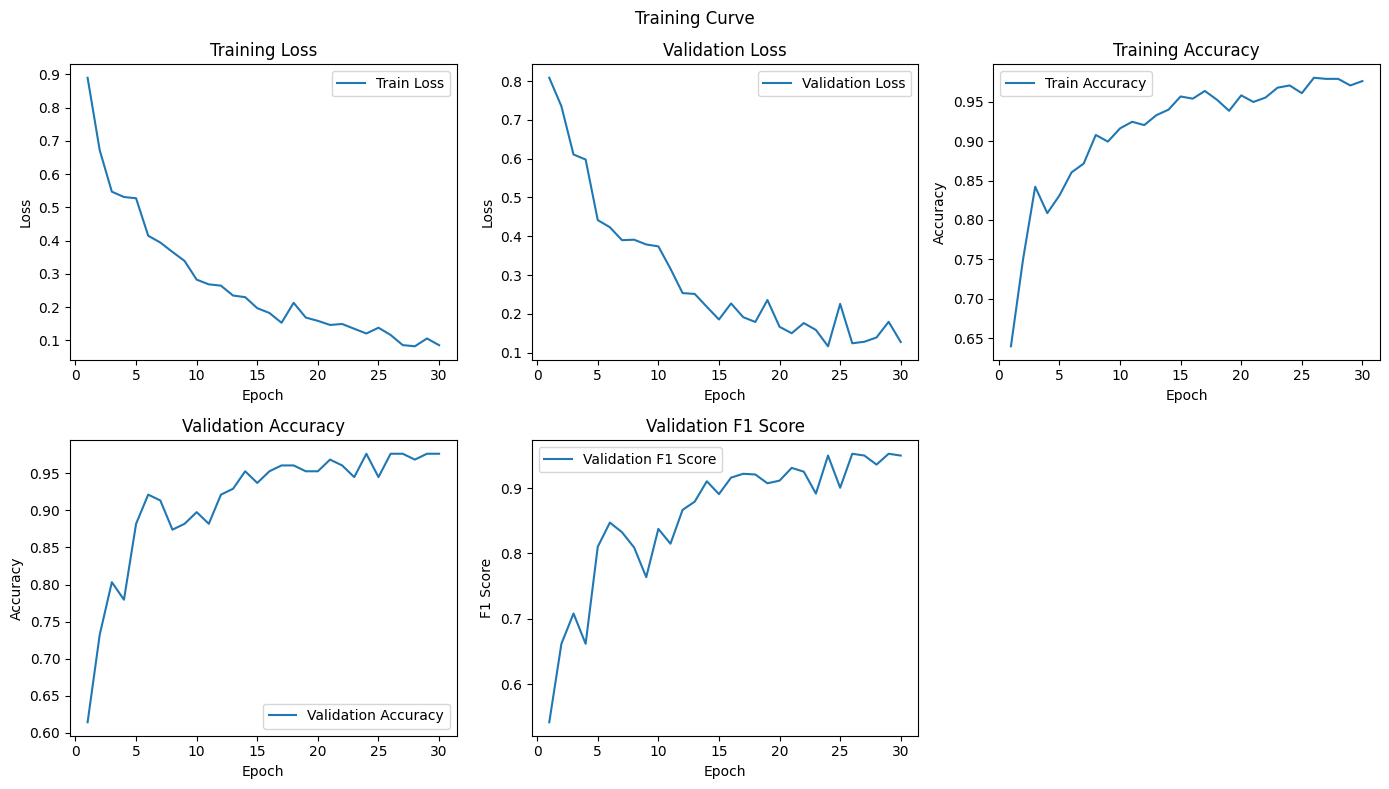

In [7]:
for model in models:
    for sheet in sheet_name:
        df = pd.read_excel(f"results/ensemble/experiment_logs/{model}/expriment_logs.xlsx",sheet_name=sheet)
        history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": [],
            "val_f1": []
        }
        for _, row in df.iterrows():
            history = {
                "train_loss": df["Train Loss"].tolist(),
                "val_loss": df["Val Loss"].tolist(),
                "train_acc": df["Train Acc"].tolist(),
                "val_acc": df["Val Acc"].tolist(),
                "val_f1": df["Val F1"].tolist()
            } 
        plot_training_curve(history,f"results/training_curve/ensemble/{model}/{sheet}.png")
    

In [16]:
import pandas as pd

In [29]:
df = pd.read_csv("results/report/ensemble/resnet_vgg_b0_inception.csv")

In [30]:
df.head()

,Model,Test_Accuracy,Precision,Recall,F1,Epochs,prep_windowing,prep_clahe,prep_median,prep_norm_type,prep_sharpen_flag
0,soft_ensemble_baseline_ep100,0.962085,0.961751,0.962085,0.961186,100,NaN,NaN,NaN,NaN,NaN
1,weighted_ensemble_baseline_ep100,0.962085,0.961751,0.962085,0.961186,100,NaN,NaN,NaN,NaN,NaN
2,soft_ensemble_windowing_ep100,0.981043,0.982276,0.981043,0.981439,100,True,NaN,NaN,NaN,NaN
3,weighted_ensemble_windowing_ep100,0.981043,0.982276,0.981043,0.981439,100,True,NaN,NaN,NaN,NaN
4,soft_ensemble_window_clahe_ep100,0.957346,0.963616,0.957346,0.959359,100,True,True,NaN,NaN,NaN


In [31]:
ensemble_models = ["soft","weighted","ensemble"]

In [32]:
def extract_info(name):
    print(name)
    parts = name.split("_")
    

    ensemble_model = []
    config_parts = []    
    epoch = None
    for p in parts:
        if p in ensemble_models:
            ensemble_model.append(p)
        elif p.startswith("ep"):
            epoch = int(p.replace("ep"," "))
        else:
            config_parts.append(p)
        
    
    parts = [p for p in parts if not p.startswith("ep")]

    ensemble_model = "_".join(ensemble_model)

    config = "_".join(config_parts)


    return pd.Series([ensemble_model,config,epoch])

df[["ensemble_model","config","epoch"]] = df["Model"].apply(extract_info)

print(df.head())

soft_ensemble_baseline_ep100
weighted_ensemble_baseline_ep100
soft_ensemble_windowing_ep100
weighted_ensemble_windowing_ep100
soft_ensemble_window_clahe_ep100
weighted_ensemble_window_clahe_ep100
soft_ensemble_clahe_median_ep100
weighted_ensemble_clahe_median_ep100
soft_ensemble_window_clahe_zscore_ep100
weighted_ensemble_window_clahe_zscore_ep100
soft_ensemble_full_medical_pipeline_ep100
weighted_ensemble_full_medical_pipeline_ep100
soft_ensemble_clahe_ep100
weighted_ensemble_clahe_ep100
                               Model  Test_Accuracy  Precision    Recall  \
0       soft_ensemble_baseline_ep100       0.962085   0.961751  0.962085   
1   weighted_ensemble_baseline_ep100       0.962085   0.961751  0.962085   
2      soft_ensemble_windowing_ep100       0.981043   0.982276  0.981043   
3  weighted_ensemble_windowing_ep100       0.981043   0.982276  0.981043   
4   soft_ensemble_window_clahe_ep100       0.957346   0.963616  0.957346   

         F1  Epochs prep_windowing prep_clahe pre

['soft_ensemble' 'weighted_ensemble']


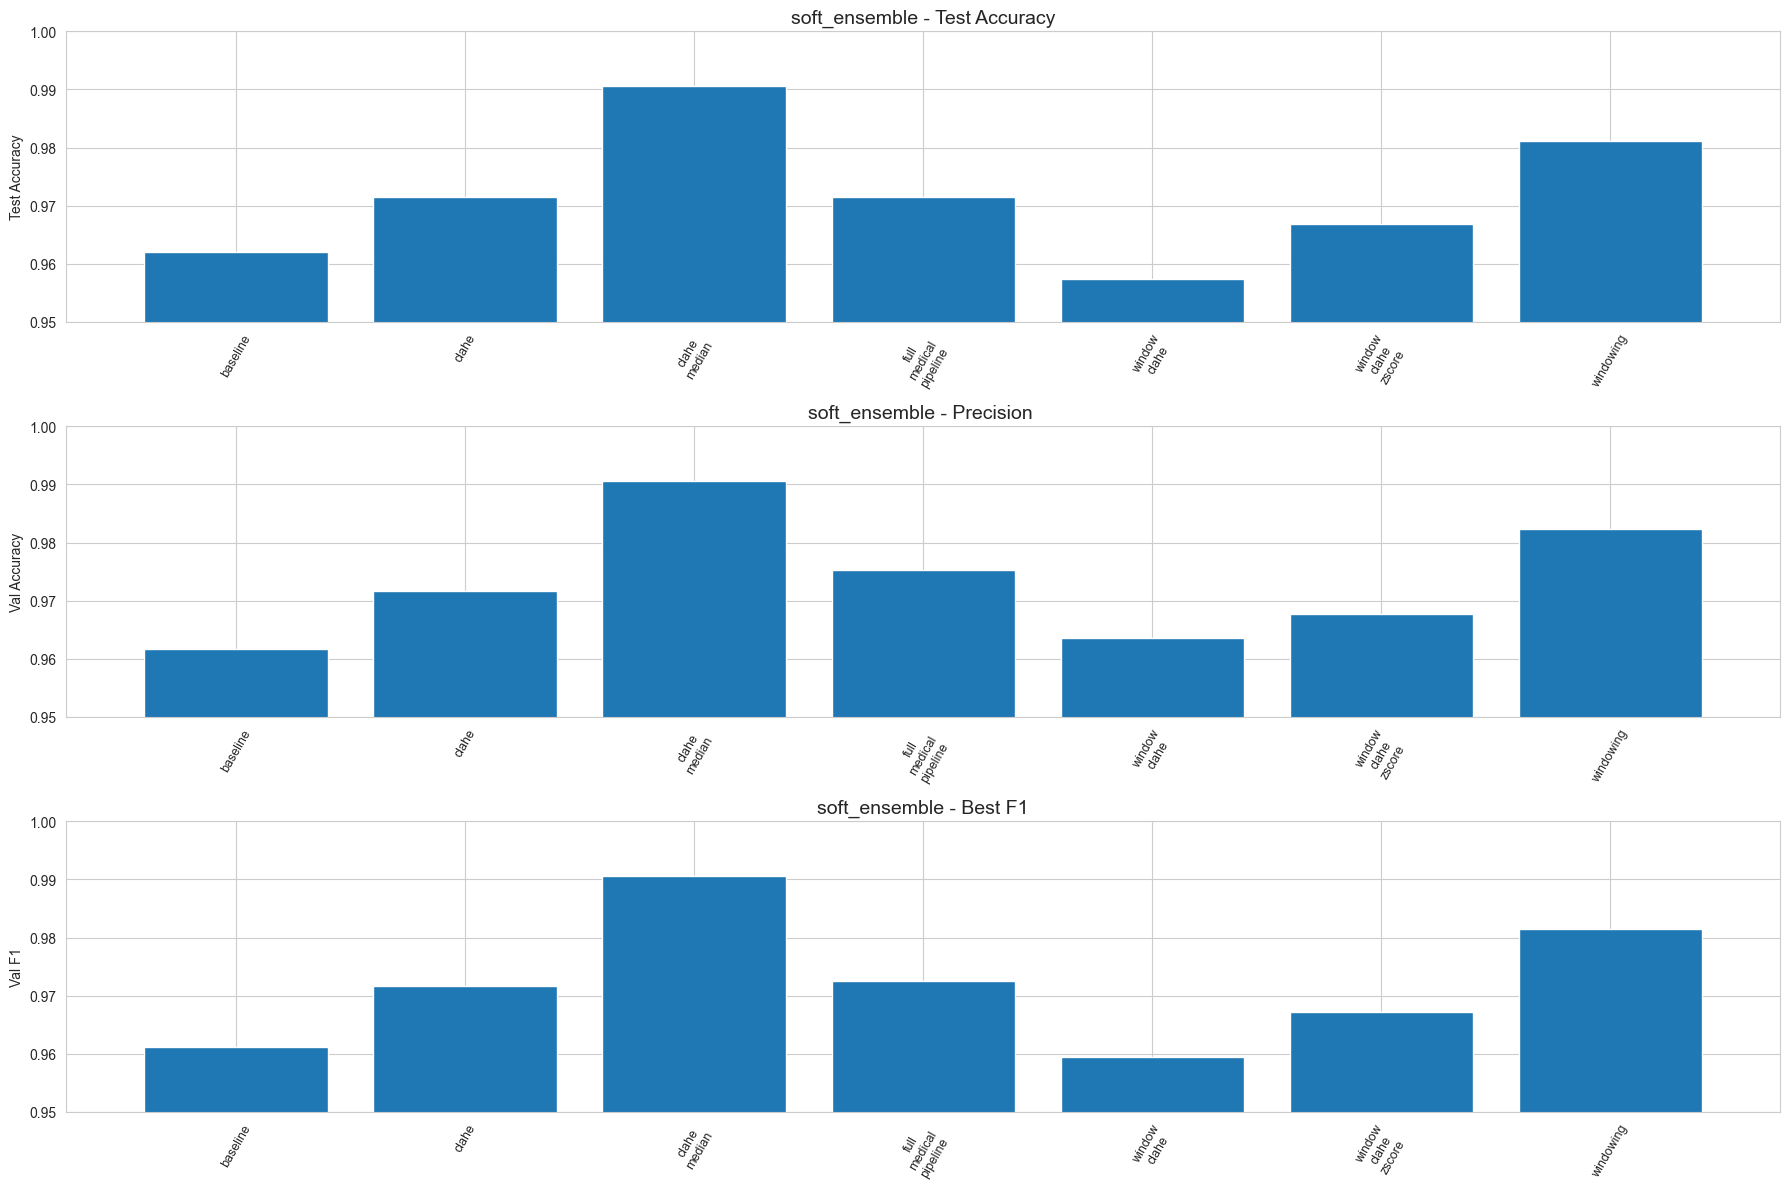

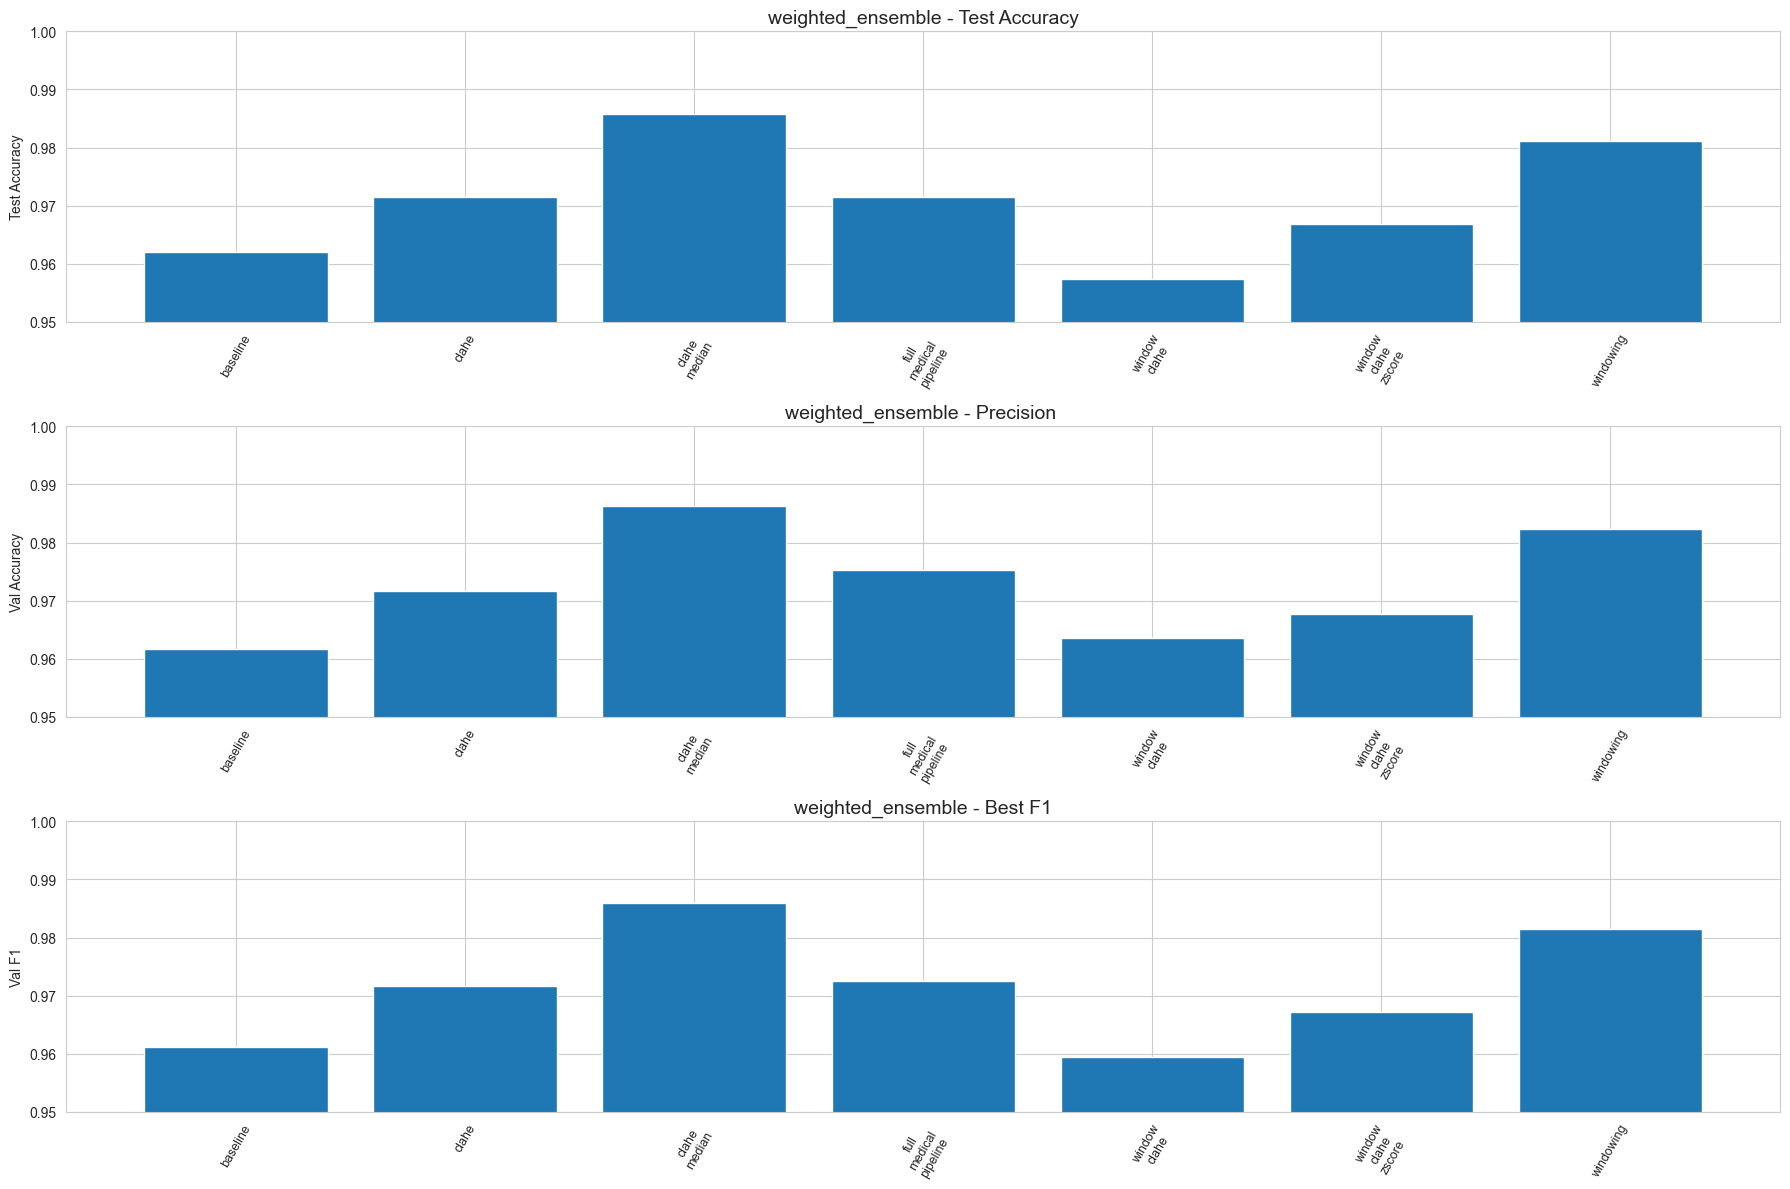

Charts generated successfully!


In [33]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/charts/ensemble", exist_ok=True)

models = df["ensemble_model"].unique()
print(models)

for model in models:

    model_df = df[df["ensemble_model"] == model]
    model_df = model_df.sort_values("config")

    # MULTILINE LABELS (fix overlap)
    configs = [c.replace("_", "\n") for c in model_df["config"]]

    # create single figure with 3 charts
    fig, axes = plt.subplots(3, 1, figsize=(18, 12))

    # -------- Test Accuracy --------
    axes[0].bar(configs, model_df["Test_Accuracy"])
    axes[0].set_title(f"{model} - Test Accuracy", fontsize=14)
    axes[0].set_ylabel("Test Accuracy")
    axes[0].set_ylim(0.95, 1)
    axes[0].tick_params(axis='x', rotation=60, labelsize=9)

    # -------- Validation Accuracy --------
    axes[1].bar(configs, model_df["Precision"])
    axes[1].set_title(f"{model} - Precision ", fontsize=14)
    axes[1].set_ylabel("Val Accuracy")
    axes[1].set_ylim(0.95, 1)
    axes[1].tick_params(axis='x', rotation=60, labelsize=9)

    # -------- Validation F1 --------
    axes[2].bar(configs, model_df["F1"])
    axes[2].set_title(f"{model} - Best F1", fontsize=14)
    axes[2].set_ylabel("Val F1")
    axes[2].set_ylim(0.95, 1)
    axes[2].tick_params(axis='x', rotation=60, labelsize=9)

    plt.tight_layout()
    plt.savefig(f"results/charts/ensemble/rvbi_{model}_performance.png")
    plt.show()
    plt.close()

print("Charts generated successfully!")

C:\Users\navne\AppData\Local\Temp\ipykernel_13984\3366367341.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_13984\3366367341.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_13984\3366367341.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


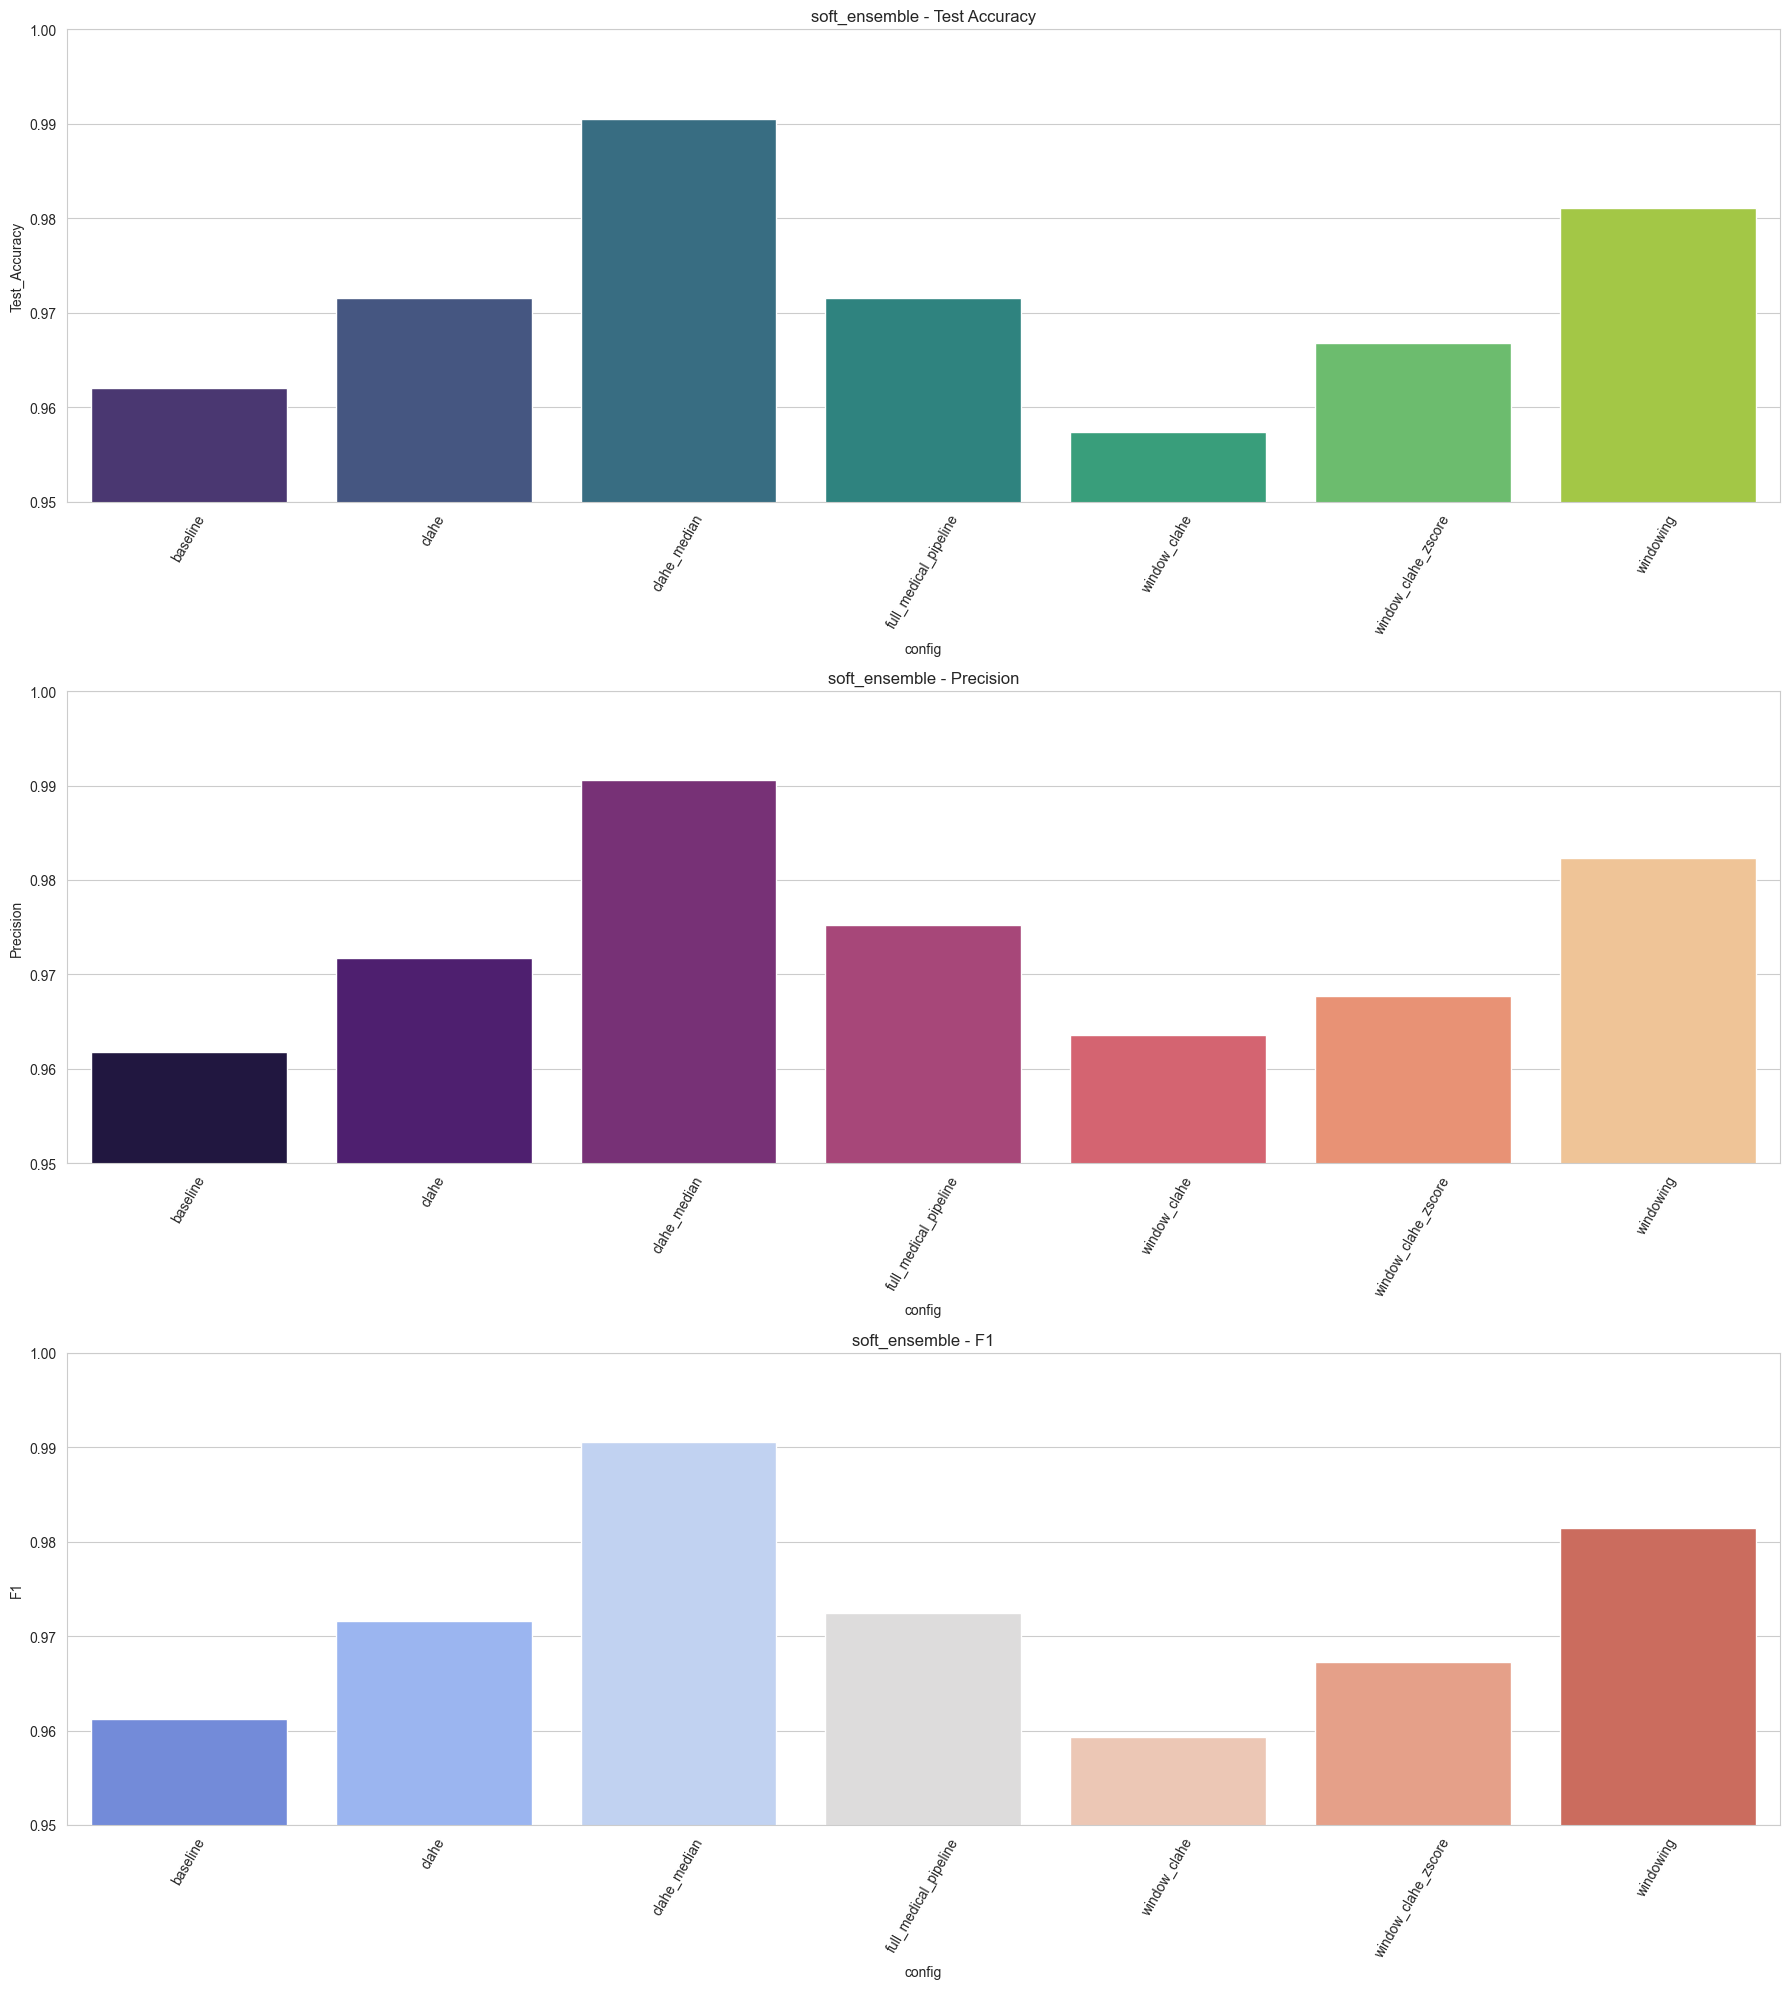

C:\Users\navne\AppData\Local\Temp\ipykernel_13984\3366367341.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_13984\3366367341.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_13984\3366367341.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


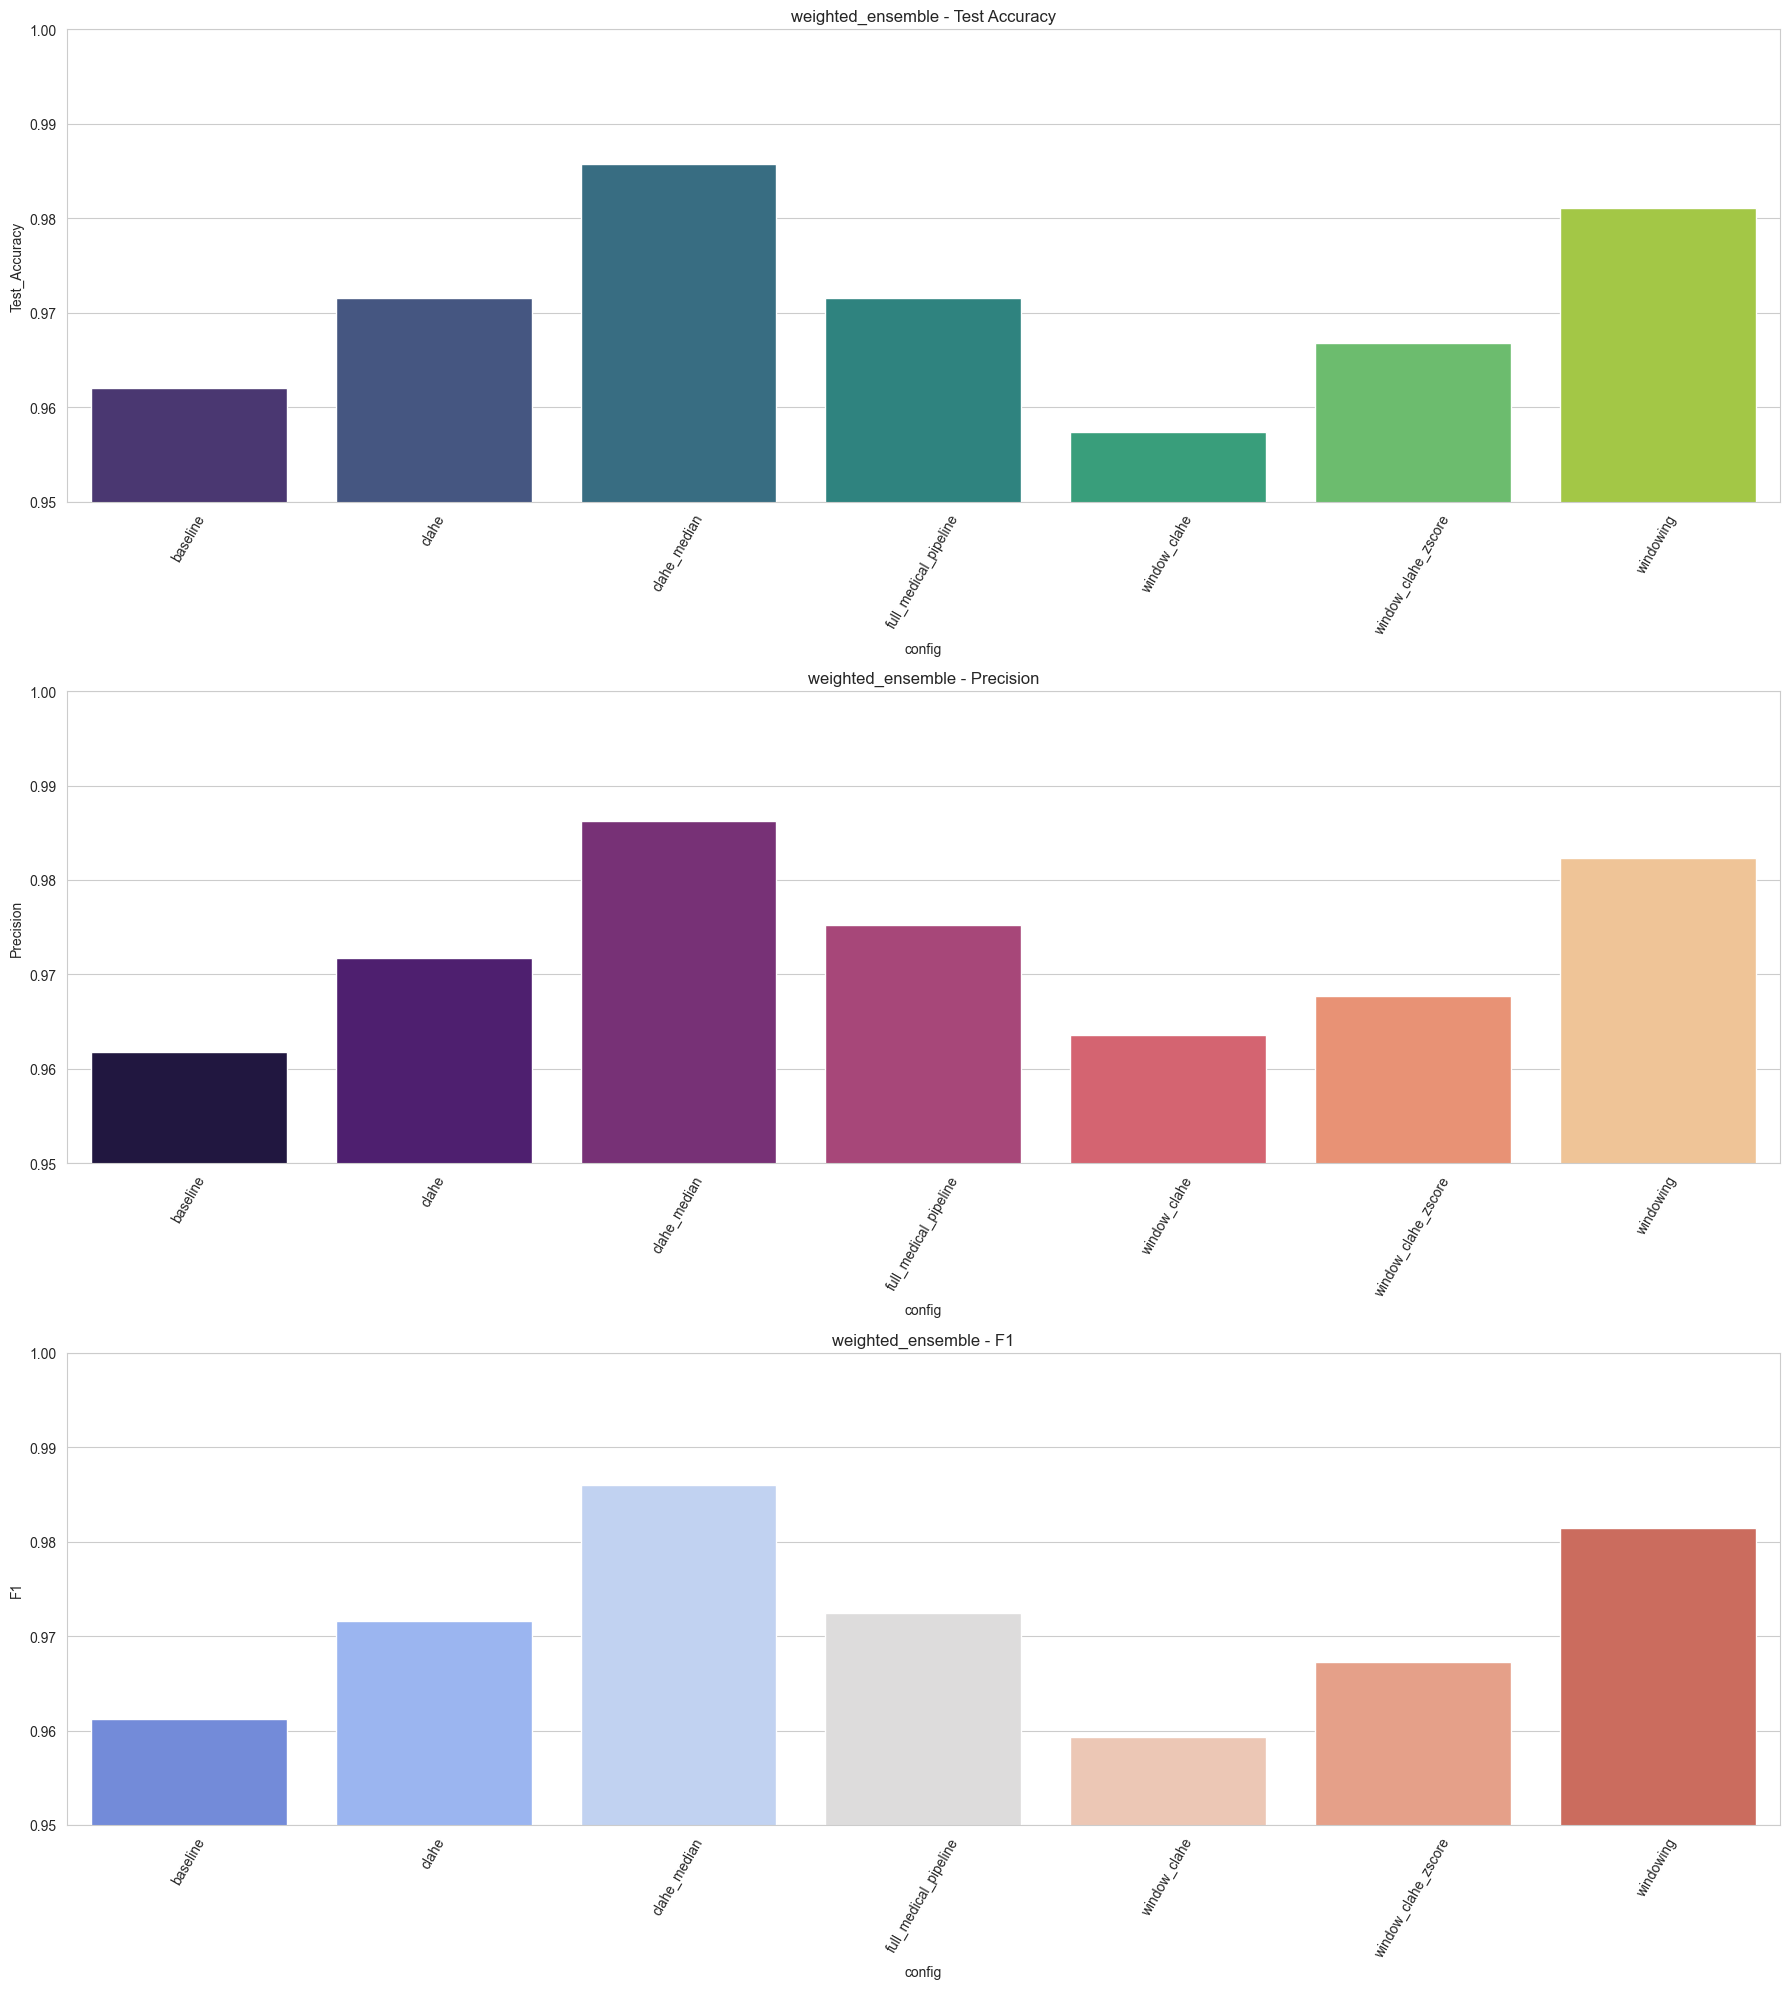

Charts generated successfully!


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("results/charts-seaborn/hybrid", exist_ok=True)

sns.set_style("whitegrid")

models = df["ensemble_model"].unique()

range = 0.95

for model in models:

    model_df = df[df["ensemble_model"] == model]
    model_df = model_df.sort_values("config")

    fig, axes = plt.subplots(3, 1, figsize=(18, 20))

    # -------- Test Accuracy --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Test_Accuracy",
        ax=axes[0],
        palette="viridis"
    )

    axes[0].set_title(f"{model} - Test Accuracy")
    axes[0].set_ylim(range, 1)
    axes[0].tick_params(axis='x', rotation=60)

    # -------- Validation Accuracy --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Precision",
        ax=axes[1],
        palette="magma"
    )

    axes[1].set_title(f"{model} - Precision")
    axes[1].set_ylim(range, 1)
    axes[1].tick_params(axis='x', rotation=60)

    # -------- Validation F1 --------
    sns.barplot(
        data=model_df,
        x="config",
        y="F1",
        ax=axes[2],
        palette="coolwarm"
    )

    axes[2].set_title(f"{model} - F1")
    axes[2].set_ylim(range, 1)
    axes[2].tick_params(axis='x', rotation=60)

    plt.tight_layout()
    plt.savefig(f"results/charts-seaborn/rvbi_{model}_performance.png")
    plt.show()
    plt.close()

print("Charts generated successfully!")

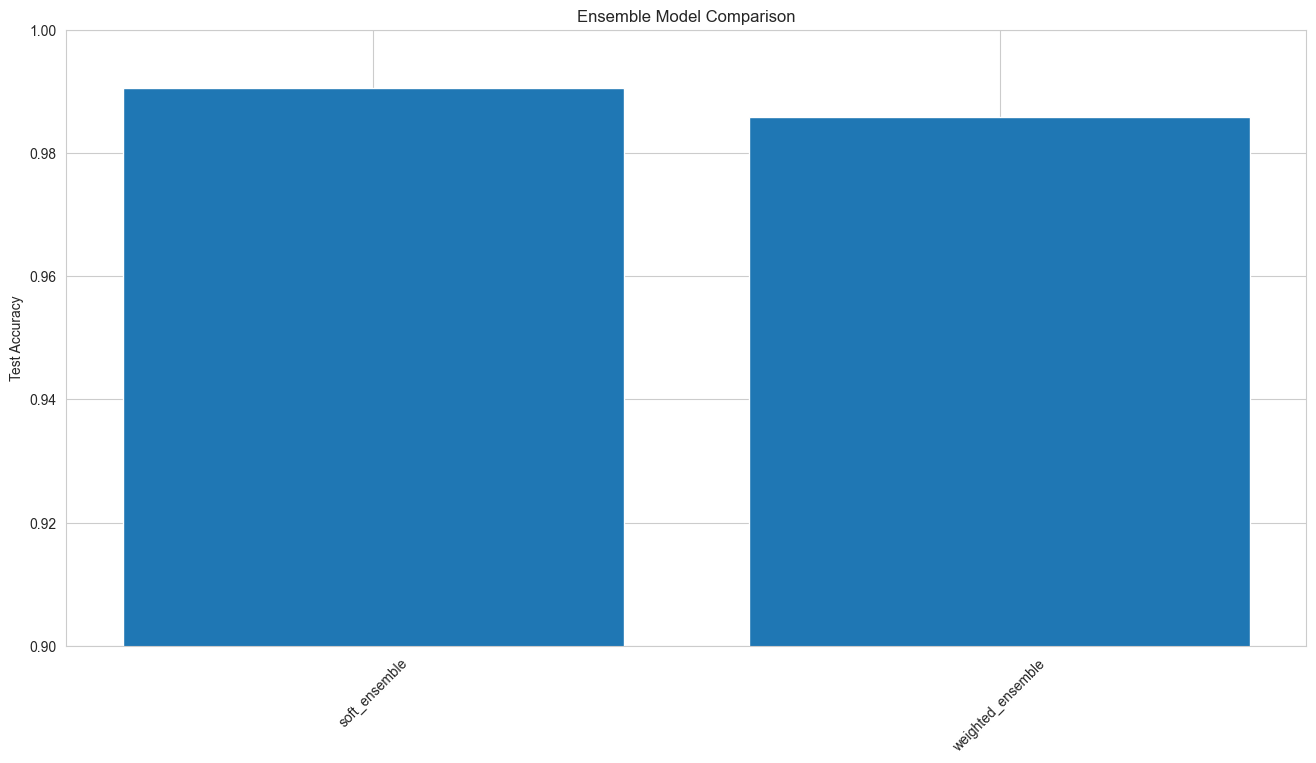

In [35]:
best_models = df.loc[df.groupby("ensemble_model")["Test_Accuracy"].idxmax()]
os.makedirs("results/charts/comparison",exist_ok=True)

plt.figure(figsize=(16,8))
plt.bar(best_models["ensemble_model"], best_models["Test_Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Test Accuracy")
plt.ylim(0.90,1)
plt.savefig("results/charts/comparison/rvbi_ensemble_model_comparison.png")
plt.title("Ensemble Model Comparison")
plt.show()

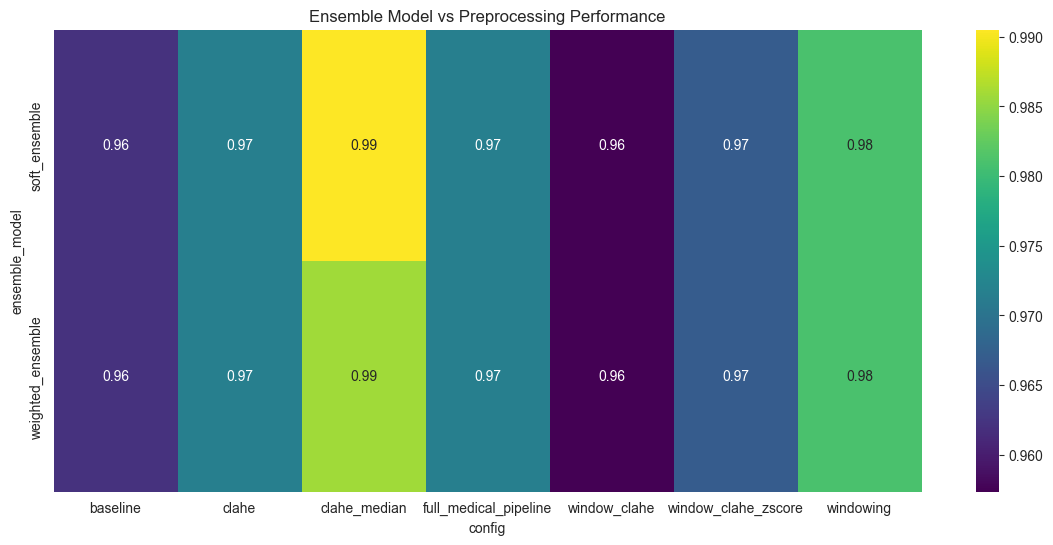

In [36]:
import seaborn as sns

pivot = df.pivot(index="ensemble_model", columns="config", values="Test_Accuracy")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Ensemble Model vs Preprocessing Performance")
plt.savefig("results/charts/heatmap/rvbi_ensemble_model_heatmap.png")
plt.show()